# scATAC clustering, annotation and gene activity

The [first tutorial](t_epi_01_atac_preprocess) took a raw fragments file to a tile matrix. Here we
pick up from a larger, **published and annotated** dataset — the 10x **PBMC 5k** scATAC reference —
to cover the downstream half of a single-cell ATAC analysis with `ov.epi`:

1. load an annotated tile-matrix AnnData (`ov.epi.datasets.atac_pbmc5k(annotated=True)`)
2. compute an ArchR-style iterative-LSI embedding and cluster it
3. visualise the published cell-type labels on UMAP
4. compute **gene-activity scores** from tile accessibility (`ov.epi.tl.add_gene_score_matrix`)
   and use canonical PBMC marker genes to confirm the annotation

Gene-activity scores are the scATAC analogue of gene expression: they aggregate accessibility over
each gene body + promoter, giving an interpretable, gene-level view of an otherwise peak-level assay.
Everything downloads on demand and runs on CPU.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1


## 1 · Load the annotated PBMC 5k dataset

The annotated build ships a 500 bp tile matrix, per-cell QC, a `cell_type` column with the
published labels, and a precomputed spectral embedding. We start from the tiles and rebuild the
embedding ourselves with `ov.epi`.

In [2]:
adata = ov.epi.datasets.atac_pbmc5k(annotated=True)
print(adata)
adata.obs['cell_type'].value_counts()

AnnData object with n_obs × n_vars = 4437 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'cell_type'
    var: 'count', 'selected'
    uns: 'cell_type_colors', 'doublet_rate', 'frag_size_distr', 'leiden_colors', 'reference_sequences', 'scrublet_sim_doublet_score', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap', 'fragment_paired'
    obsp: 'distances'


cell_type
cDC           842
CD14 Mono     658
CD4 Memory    599
CD8 Memory    526
CD4 Naive     444
Memory B      276
CD8 Naive     262
MAIT          246
NK            236
CD16 Mono     168
Naive B       146
pDC            34
Name: count, dtype: int64

## 2 · Iterative LSI, neighbors and UMAP

`ov.epi.tl.iterative_lsi` recomputes the ArchR-style embedding on the selected tile features.
We then build the neighbor graph and a UMAP — the same verbs as the RNA pipeline, just on
accessibility.

In [3]:
ov.epi.tl.iterative_lsi(adata, n_components=30, iterations=2)
ov.epi.pp.neighbors(adata, use_rep='X_iterative_lsi')
ov.epi.tl.umap(adata)
print('embeddings:', list(adata.obsm.keys()))

  └─ [iterative_lsi] Initial feature set: 500,000 / 6,062,095


  └─ [iterative_lsi] Iter 1/2 | fit on 4,437 cells x 500,000 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)


running Leiden clustering


...

  └─ [iterative_lsi]   -> 7 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 4,437 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (4,437 x 29) in adata.obsm['X_iterative_lsi']
Computing neighbors with n_neighbors=15


Finished computing neighbors
    Added to .uns['neighbors']
    .obsp['distances'], distances for each pair of neighbors
    .obsp['connectivities'], weighted adjacency matrix
Computing UMAP embedding...


    Finished computing UMAP
    Added:
        'X_umap', UMAP coordinates (adata.obsm)
        'umap', UMAP parameters (adata.uns)
embeddings: ['X_spectral', 'X_umap', 'fragment_paired', 'X_iterative_lsi']


## 3 · Cell types on the UMAP

Colouring the fresh UMAP by the published `cell_type` labels shows the major PBMC lineages —
T cells, B cells, monocytes, NK and dendritic cells — separating cleanly on accessibility alone.

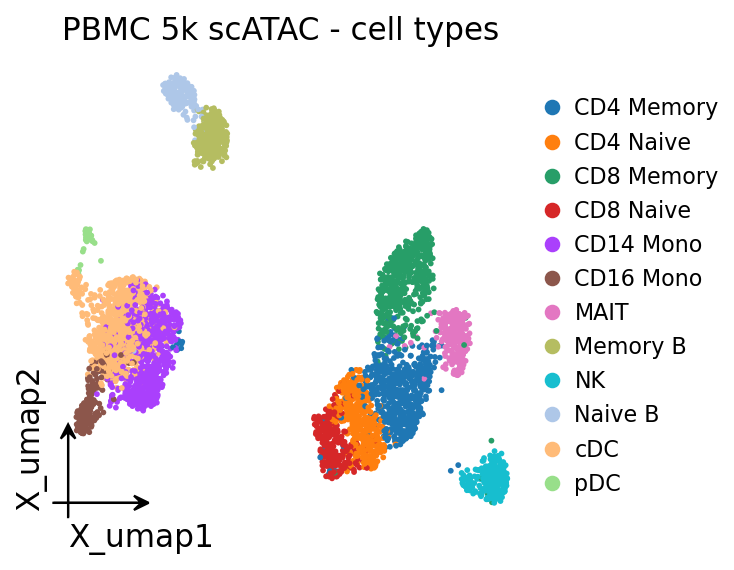

In [4]:
# omicverse embedding plotter, coloured by the published cell types.
ov.pl.embedding(adata, basis='X_umap', color='cell_type', frameon='small',
                title='PBMC 5k scATAC - cell types', show=False)
plt.show()

## 4 · Gene-activity scores

`ov.epi.tl.add_gene_score_matrix` builds a cell × gene activity matrix by aggregating tile
accessibility over each gene (distance-weighted, ArchR-style). The result lands in
`adata.obsm['gene_score']` with gene names in `adata.uns['gene_score_gene_names']`.

In [5]:
genome = ov.epi.data.hg38
genes = ov.epi.io.get_gene_annotation(genome)
ov.epi.tl.add_gene_score_matrix(adata, genes)

gene_score = np.asarray(adata.obsm['gene_score'])
gene_names = np.asarray(adata.uns['gene_score_gene_names'])
print('gene activity matrix:', gene_score.shape)

  └─ [gene_score] genes: 19,923 on 23 chroms (after excluding ['chrY', 'chrM'])


  └─ [gene_score] input: adata.X (already a tile matrix)


  └─ [gene_score] source=adata.X  cells=4,437  tiles=6,062,095  nnz=81M


  └─ [gene_score] tile→gene W: (6062095, 19923)  nnz=5.1M


  └─ [gene_score] computing gene_score = X_tile @ W


  └─ [gene_score] done. obsm['gene_score'] = (4437, 19923) float32 (uns[gene_score_gene_names]: 19,923 genes)


gene activity matrix: (4437, 19923)


### Marker gene activity on the UMAP

Canonical PBMC markers should light up in the expected lineages: **CD3D** (T cells),
**MS4A1 / CD79A** (B cells), **CD14 / LYZ** (monocytes), **NKG7** (NK), **FCGR3A** (CD16
monocytes / NK).

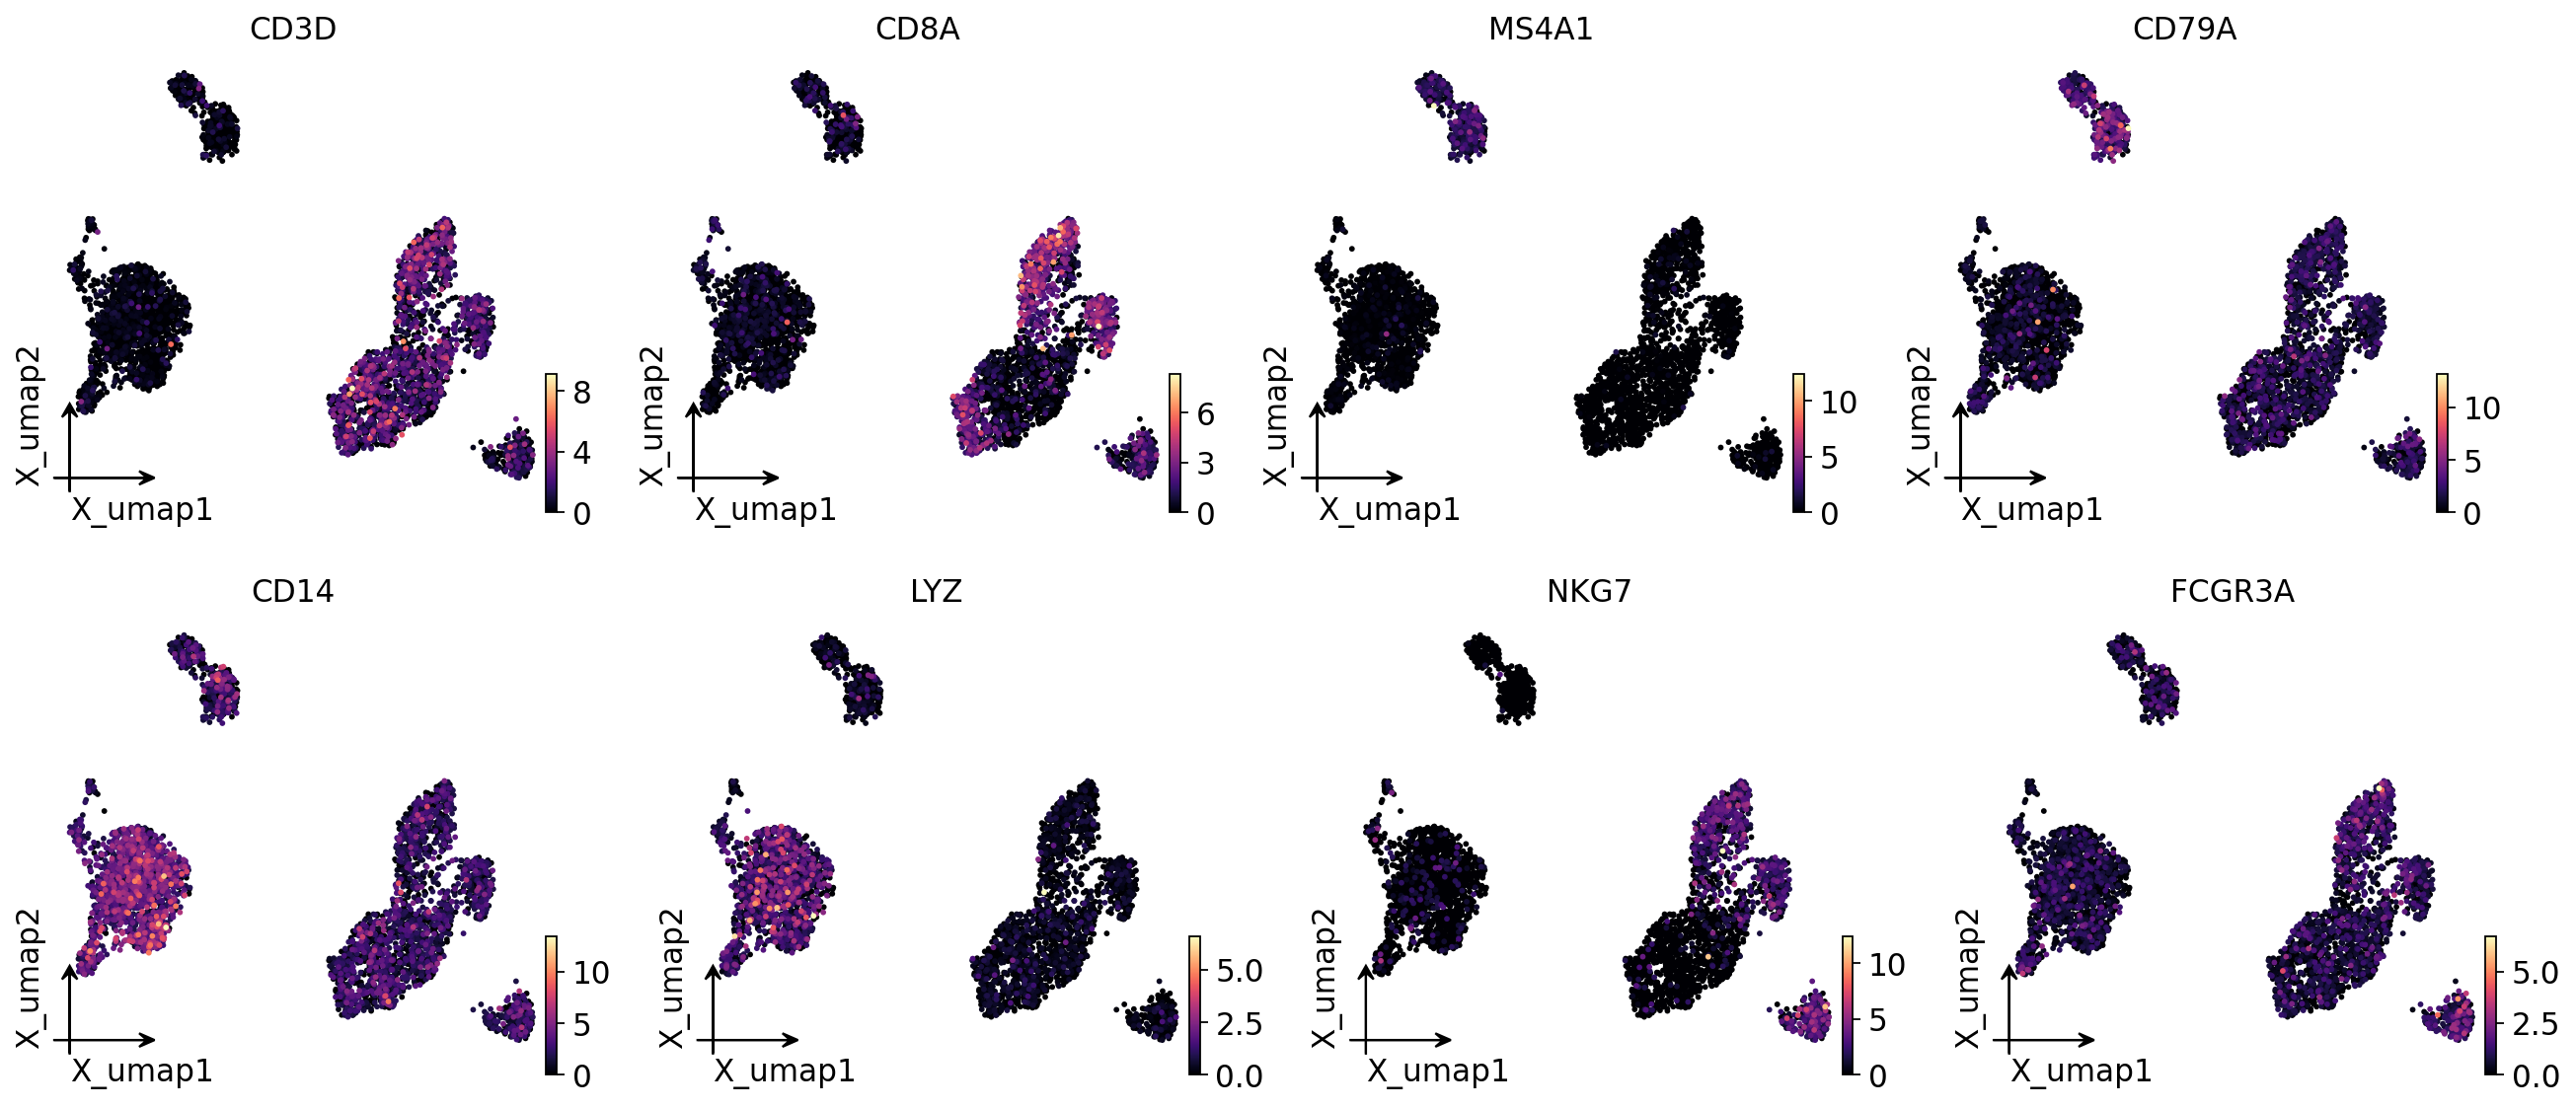

In [6]:
# Wrap the gene-activity scores for the canonical markers into a gene-space
# AnnData so omicverse's plotters can render them directly.
import anndata as ad
markers = ['CD3D', 'CD8A', 'MS4A1', 'CD79A', 'CD14', 'LYZ', 'NKG7', 'FCGR3A']
markers = [g for g in markers if g in set(gene_names)]
name_to_col = {g: i for i, g in enumerate(gene_names)}
ga = ad.AnnData(np.stack([gene_score[:, name_to_col[g]] for g in markers], axis=1).astype('float32'))
ga.var_names = markers
ga.obs_names = list(adata.obs_names)
ga.obs['cell_type'] = adata.obs['cell_type'].values
ga.obsm['X_umap'] = np.asarray(adata.obsm['X_umap'])

# Marker gene-activity on the UMAP (one panel per marker).
ov.pl.embedding(ga, basis='X_umap', color=markers, frameon='small', ncols=4,
                cmap='magma', show=False)
plt.show()

### Mean activity per cell type

An omicverse `dotplot` of mean marker gene-activity per cell type confirms each marker is
highest (and most broadly detected) in its expected lineage.

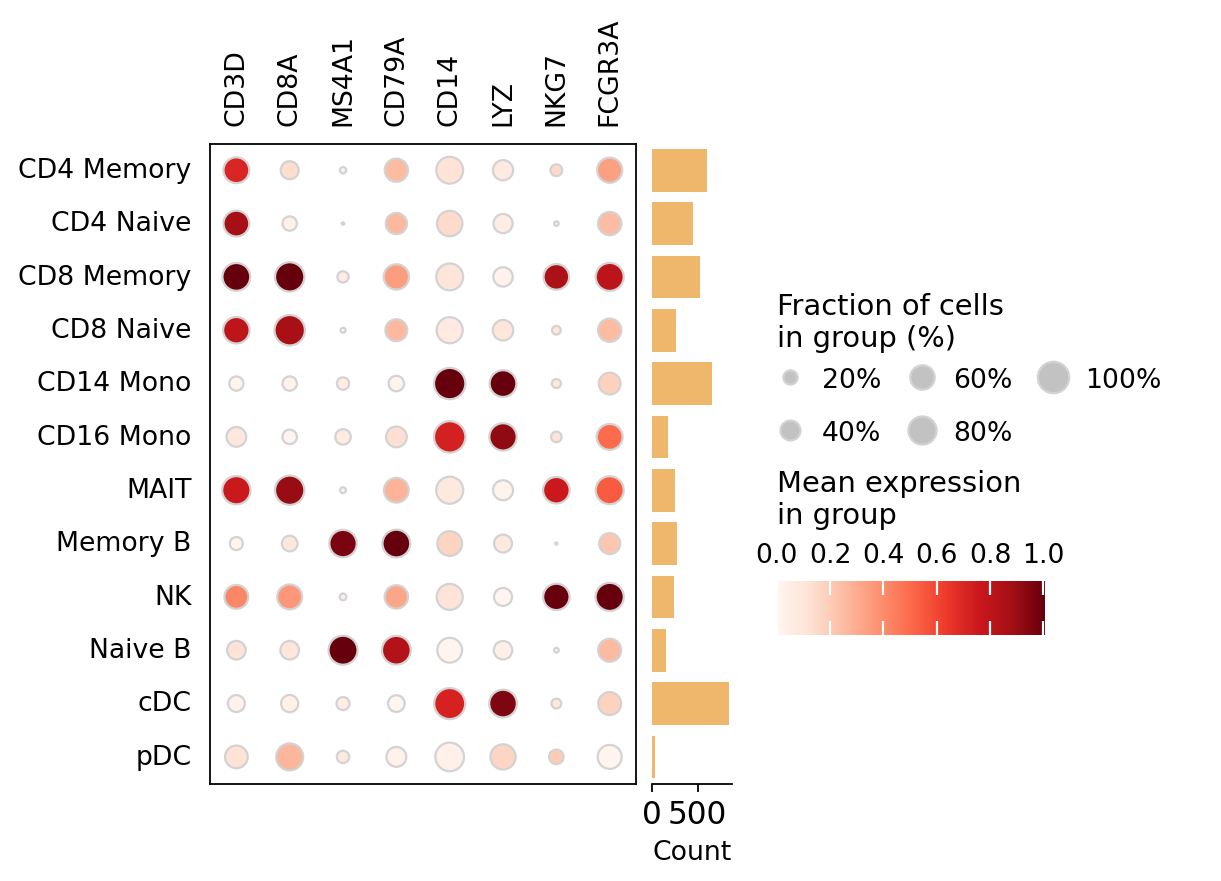

In [7]:
# Per-cell-type marker gene-activity as an omicverse dotplot.
ov.pl.dotplot(ga, var_names=markers, groupby='cell_type', use_raw=False,
              standard_scale='var', show=False)
plt.show()

## Summary

| stage | function |
|---|---|
| load annotated tiles | `ov.epi.datasets.atac_pbmc5k(annotated=True)` |
| embed | `ov.epi.tl.iterative_lsi`, `ov.epi.pp.neighbors`, `ov.epi.tl.umap` |
| gene activity | `ov.epi.tl.add_gene_score_matrix` → `obsm['gene_score']` |

Gene-activity scores connect the accessibility landscape back to genes, letting you reuse
RNA-style markers to interpret scATAC clusters. The next tutorial scores **transcription-factor
motif activity** per cell with chromVAR.